# P452 Project 1 — Quantum Computer Simulator

This notebook covers the full backend development and all checkpoint questions.

## Setup

In [87]:
!pip install qiskit qiskit-aer matplotlib numpy -q
!pip install pylatexenc

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

# 10-qubit AerSimulator backend
simulator = AerSimulator()
print('Backend ready:', simulator.name)

Backend ready: aer_simulator


## Q1.2 — Parameter Control Loop

Counts: {'11': 1024}


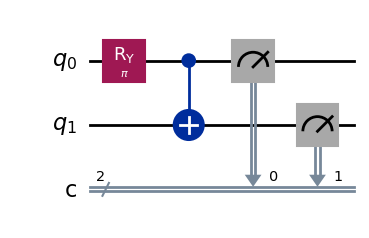

In [89]:
theta = np.pi  # θ = π

qc = QuantumCircuit(2, 2)
qc.ry(theta, 0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()
print('Counts:', counts)

qc.draw('mpl')

### Logic Check
- `Ry(π)|0⟩ = |1⟩` (rotates by π on Bloch sphere → |0⟩ flips to |1⟩)
- CNOT with control=|1⟩ flips target: q1 → |1⟩
- Final state: |11⟩ with ~100% probability
- Any wrong θ would give a different distribution → |11⟩ uniquely identifies θ=π

## Q1.3 — 10-Qubit GHZ State

{'1111111111': 512, '0000000000': 512}


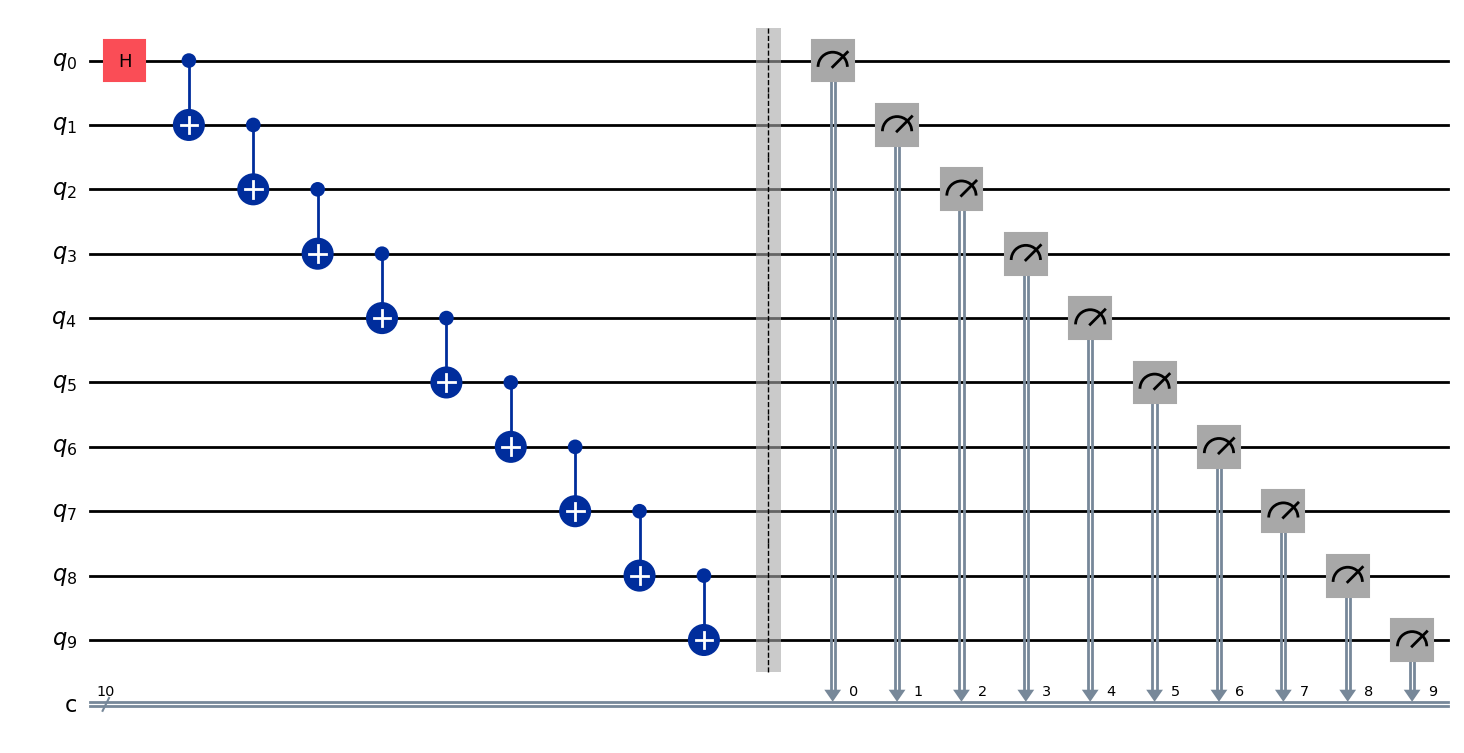

In [90]:
n = 10
qc_ghz = QuantumCircuit(n, n)
qc_ghz.h(0)
for i in range(n - 1):
    qc_ghz.cx(i, i + 1)
qc_ghz.barrier()
qc_ghz.measure(range(n), range(n))

result = simulator.run(qc_ghz, shots=1024).result()
print(result.get_counts())
qc_ghz.draw('mpl', fold=-1)

## Q1.4 — Unitarity & State Recovery

State prep verified: non-zero indices = [201, 425]

Step 1 — Initial state:
  (1/√2)|201⟩ + (1/√2)|425⟩
  |201⟩ = 0011001001   |425⟩ = 0110101001
  Probabilities: {'0011001001': 0.5, '0110101001': 0.5}


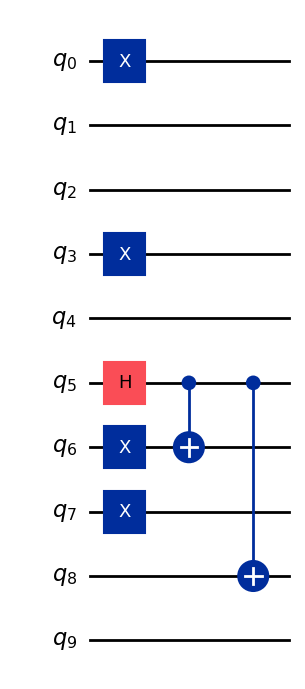

In [91]:
# Target: (1/√2)(|201⟩ + |425⟩)
# 201 = 0b0011001001, 425 = 0b0110101001 (Qiskit little-endian: q0 = bit 0)

n = 10

# ── State-prep helper: builds (|201⟩ + |425⟩)/√2 from |0...0⟩ using explicit gates.
# This avoids initialize() which dumps the full 1024-element vector into the gate label.
#
# Strategy:
#   |201⟩ = |0011001001⟩  (q0 is LSB: bits of 201 = 11001001)
#   |425⟩ = |0110101001⟩  (bits of 425 = 110101001)
#
#   Shared bits (same in both):  q0=1, q1=0, q3=1
#   Differing bits:              q2: 201→0, 425→0  ← wait, recheck
#
# Bit decomposition (little-endian, q0=LSB):
#   201 = 0b11001001 → q0=1,q1=0,q2=0,q3=1,q4=0,q5=0,q6=1,q7=1,q8=0,q9=0
#   425 = 0b110101001 → q0=1,q1=0,q2=0,q3=1,q4=0,q5=1,q6=0,q7=1,q8=1,q9=0
#
# Shared (same value in both): q0=1, q1=0, q2=0, q3=1, q4=0, q7=1, q9=0
# Differing: q5 (0 vs 1), q6 (1 vs 0), q8 (0 vs 1)
#
# Construction:
#   1. Set shared bits: X on q0, q3, q7
#   2. Use an ancilla-free superposition on q5 (the 'control' differing qubit):
#      H(q5) → (|0⟩+|1⟩)/√2
#   3. CNOT(q5→q6): flips q6 when q5=0  → need X(q6) then CNOT(q5,q6)
#      When q5=0: q6 stays 1 (we Xed it) = state |201⟩ component
#      When q5=1: q6 flips to 0           = state |425⟩ component
#   4. CNOT(q5→q8): q8=1 only when q5=1  = state |425⟩ component  ✓

def prepare_superposition(qc):
    """Prepare (|201⟩ + |425⟩)/√2 using explicit gates. Circuit label is compact."""
    # Shared '1' bits
    qc.x(0)   # q0=1 in both
    qc.x(3)   # q3=1 in both
    qc.x(7)   # q7=1 in both
    # Superposition over the differing bits via q5
    qc.h(5)           # q5: (|0⟩+|1⟩)/√2
    qc.x(6)           # start q6=1 (for the |201⟩ branch where q5=0)
    qc.cx(5, 6)       # flip q6 when q5=1 → q6=0 in |425⟩ branch
    qc.cx(5, 8)       # q8=1 only in |425⟩ branch (q5=1)

# Verify the construction gives exactly (|201⟩+|425⟩)/√2
qc_check = QuantumCircuit(10)
prepare_superposition(qc_check)
sv_check = Statevector(qc_check)
nonzero_check = {i: round(abs(a)**2,6) for i,a in enumerate(sv_check.data) if abs(a)>1e-6}
assert set(nonzero_check.keys()) == {201, 425}, f'Unexpected states: {nonzero_check}'
print('State prep verified: non-zero indices =', list(nonzero_check.keys()))

# ── Step 1: Initial State ──
qc1 = QuantumCircuit(n)
prepare_superposition(qc1)
sv_init = Statevector(qc1)

print('\nStep 1 — Initial state:')
print('  (1/√2)|201⟩ + (1/√2)|425⟩')
print('  |201⟩ =', format(201,'010b'), '  |425⟩ =', format(425,'010b'))
nonzero_init = {format(i,'010b'): round(abs(a)**2,6)
                for i,a in enumerate(sv_init.data) if abs(a)>1e-6}
print('  Probabilities:', nonzero_init)

# Draw Step 1 circuit — now shows clean X/H/CNOT gates, no giant label
qc1.draw('mpl')

Step 2 — After CNOT chain, non-zero states:
  |0001000111⟩  p = 0.5000
  |1101100111⟩  p = 0.5000


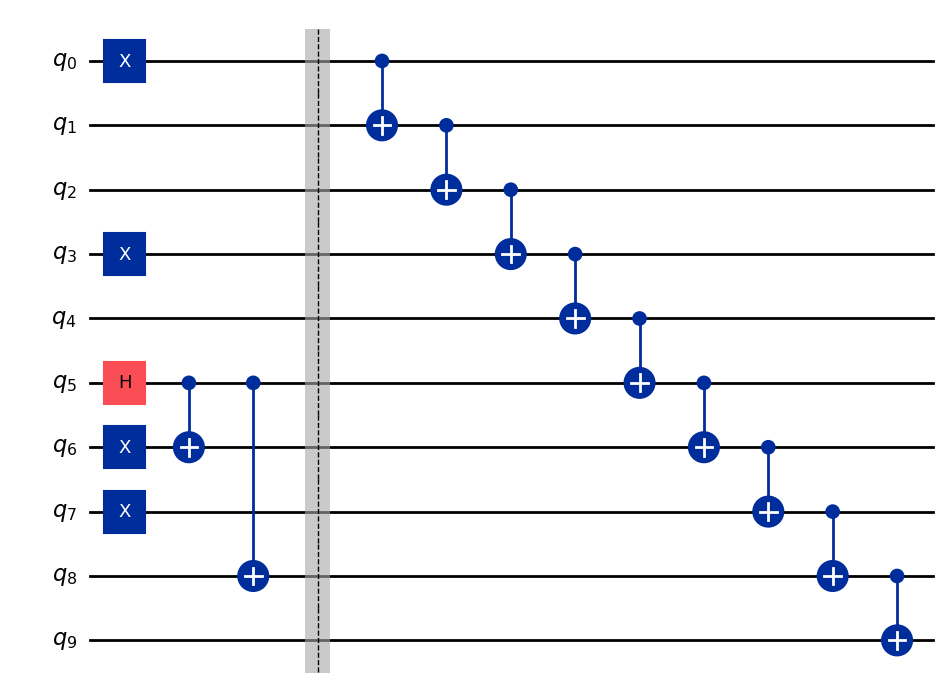

In [92]:
# ── Step 2: Apply CNOT chain ──
qc2 = QuantumCircuit(n)
prepare_superposition(qc2)
qc2.barrier()
for i in range(9):
    qc2.cx(i, i+1)
sv_after = Statevector(qc2)

nonzero_after = {format(i,'010b'): round(abs(a)**2,6)
                 for i,a in enumerate(sv_after.data) if abs(a)>1e-6}
print('Step 2 — After CNOT chain, non-zero states:')
for state, prob in nonzero_after.items():
    print(f'  |{state}⟩  p = {prob:.4f}')

qc2.draw('mpl')

Step 3 — Recovered state:
  |0011001001⟩  p = 0.5000
  |0110101001⟩  p = 0.5000

Matches initial? True


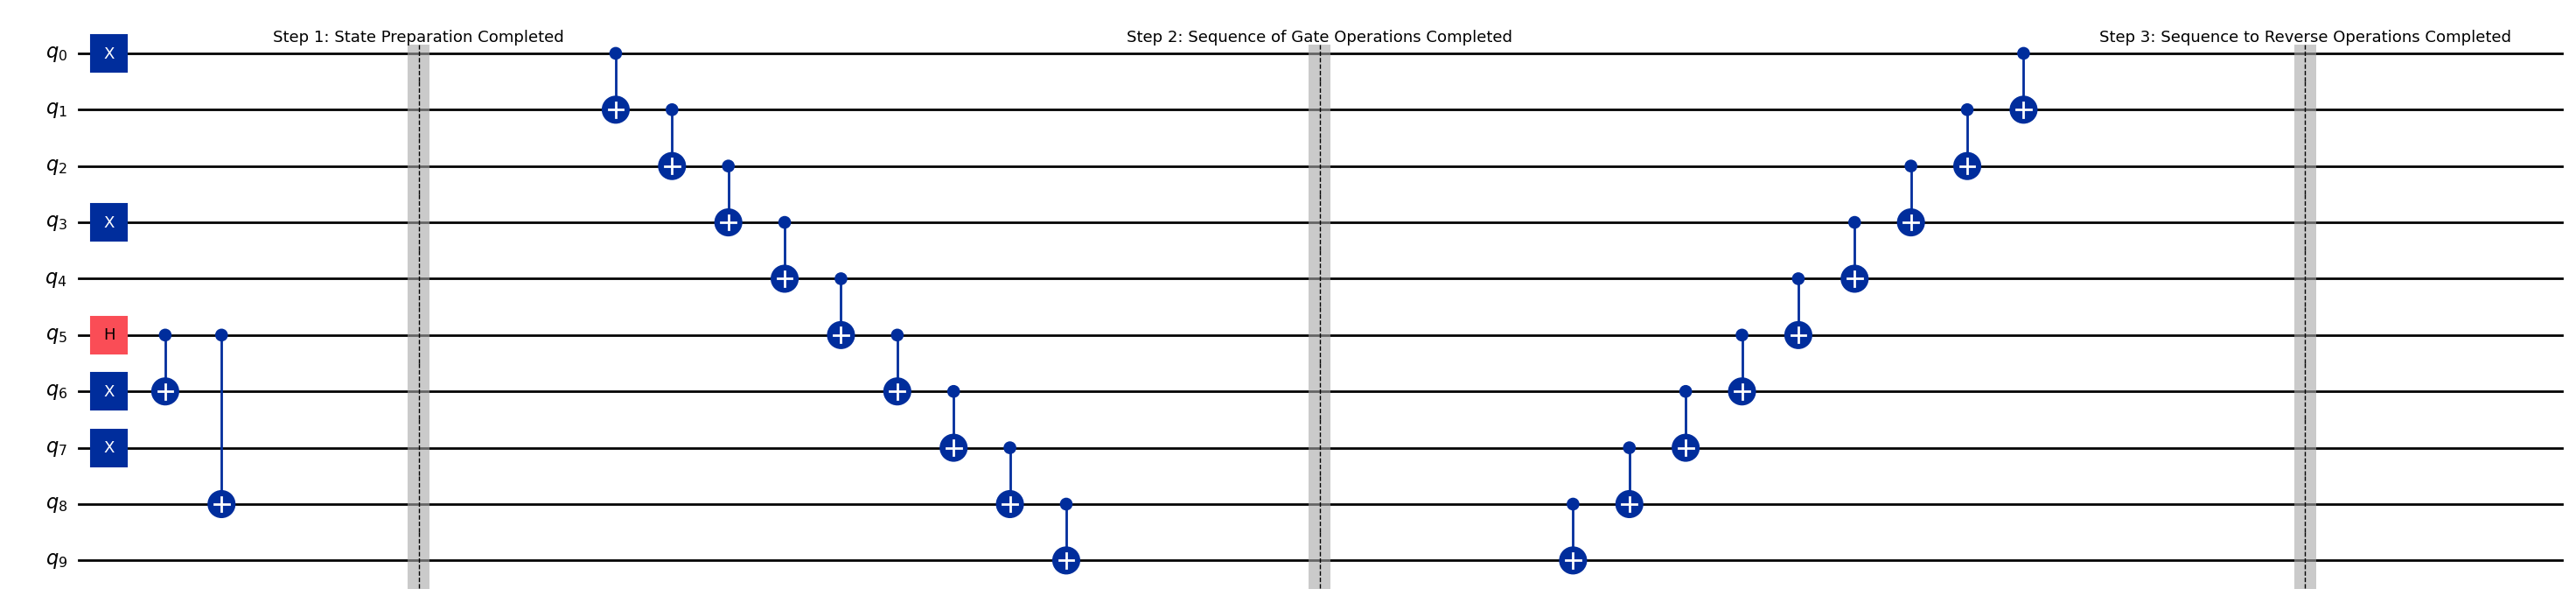

In [93]:
# ── Step 3: Full circuit with labeled sections ──
qc3 = QuantumCircuit(n)

# Section 1: State Preparation
prepare_superposition(qc3)
qc3.barrier(label='Step 1: State Preparation Completed')

# Section 2: Gate Operations (CNOT chain)
for i in range(9):
    qc3.cx(i, i+1)
qc3.barrier(label='Step 2: Sequence of Gate Operations Completed')

# Section 3: Reverse Gate Operations
for i in reversed(range(9)):
    qc3.cx(i, i+1)
qc3.barrier(label='Step 3: Sequence to Reverse Operations Completed')

sv_recovered = Statevector(qc3)

nonzero_rec = {format(i,'010b'): round(abs(a)**2,6)
               for i,a in enumerate(sv_recovered.data) if abs(a)>1e-6}
print('Step 3 — Recovered state:')
for state, prob in nonzero_rec.items():
    print(f'  |{state}⟩  p = {prob:.4f}')
print('\nMatches initial?', np.allclose(
    list(nonzero_init.values()), list(nonzero_rec.values())))

qc3.draw('mpl', fold=-1)

### Analysis: Unitarity
- Each CNOT is unitary (U†U = I)
- The chain of CNOTs forms a unitary product U = U₈...U₁U₀
- The inverse is U† = U₀†U₁†...U₈† (since each CNOT is self-inverse, U†ᵢ = Uᵢ)
- In other words, since CNOT * CNOT = I (if the control and target qubits are the same), then the sequence of gates needed to reverse our chain of 9 CNOT gates is the exact same sequence of gates applied in reverse.
- And we see that after applying reversed sequence, we recover the exact initial state → **unitarity confirmed**

## Q2.1 — Teleportation

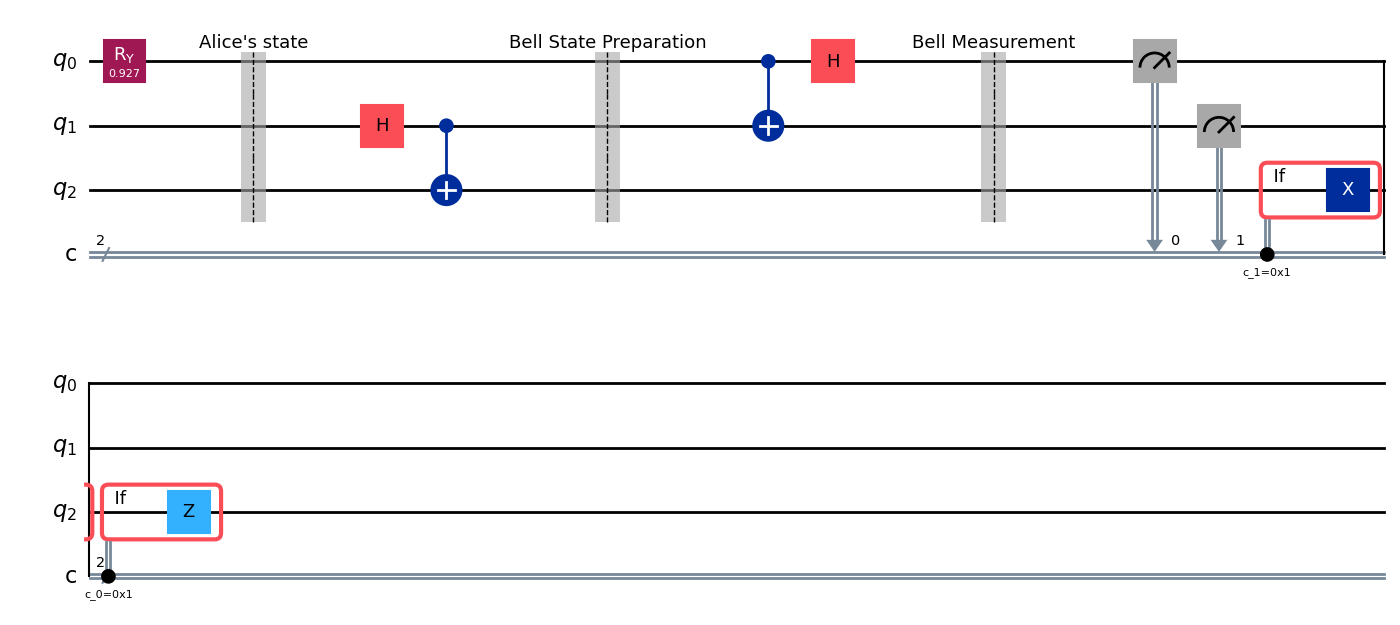

In [94]:
# Alice's state: |q0⟩ = (2|0⟩ + |1⟩)/√5
theta_alice = 2 * np.arccos(2 / np.sqrt(5))

qr = QuantumRegister(3, 'q')
cr = ClassicalRegister(2, 'c')
qc_tel = QuantumCircuit(qr, cr)

# Prepare Alice's qubit
qc_tel.ry(theta_alice, 0)
qc_tel.barrier(label='Alice\'s state')

# Bell State Preparation
qc_tel.h(1)
qc_tel.cx(1, 2)
qc_tel.barrier(label='Bell State Preparation')

# Bell Measurement
qc_tel.cx(0, 1)
qc_tel.h(0)
qc_tel.barrier(label='Bell Measurement')
qc_tel.measure(qr[0], cr[0])
qc_tel.measure(qr[1], cr[1])

# Bob's correction
with qc_tel.if_test((cr[1], 1)):
    qc_tel.x(2)
with qc_tel.if_test((cr[0], 1)):
    qc_tel.z(2)

qc_tel.draw('mpl', fold=20)

## Q2.2 — Long-Distance CNOT (q0 → q4)

Total CNOTs: 19


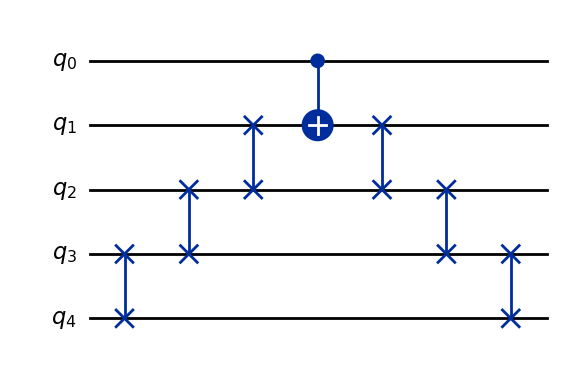

In [95]:
qc_ld = QuantumCircuit(5)
n_cnots = 0

qc_ld.swap(3,4); qc_ld.swap(2,3); qc_ld.swap(1,2)
qc_ld.cx(0,1); n_cnots += 1
qc_ld.swap(1,2); qc_ld.swap(2,3); qc_ld.swap(3,4)

n_swaps = 6
n_cnots += n_swaps*3

print(f'Total CNOTs: {n_cnots}')
qc_ld.draw('mpl')

**Answer:** 6 SWAPs (each SWAP = 3 CNOTs) + 1 direct CNOT = 6*3 + 1 = **19 total CNOT gates**

## Q2.3 — Teleportation Statistics (|0⟩ input, 1024 shots)

In [96]:
# Teleport |0⟩
qr2 = QuantumRegister(3,'q')
cr2 = ClassicalRegister(3,'c')  # measure all 3 including Bob
qc_zero = QuantumCircuit(qr2, cr2)
# Leave q0 as |0⟩
qc_zero.h(1); qc_zero.cx(1,2)
qc_zero.cx(0,1); qc_zero.h(0)
qc_zero.measure(qr2[0], cr2[0])
qc_zero.measure(qr2[1], cr2[1])
with qc_zero.if_test((cr2[1],1)): qc_zero.x(2)
with qc_zero.if_test((cr2[0],1)): qc_zero.z(2)
qc_zero.measure(qr2[2], cr2[2])

result = simulator.run(qc_zero, shots=1024).result()
counts = result.get_counts()
bob_0 = sum(v for k,v in counts.items() if k[0]=='0')  # MSB = Bob's qubit
bob_1 = sum(v for k,v in counts.items() if k[0]=='1')
print(f'Bob |0⟩: {bob_0/1024*100:.1f}%   Bob |1⟩: {bob_1/1024*100:.1f}%')

Bob |0⟩: 100.0%   Bob |1⟩: 0.0%


**Expected:** Bob finds |0⟩ ~100%. Any deviation is shot noise (~1/√1024 ≈ 3%).

## Q3 — Fermi-Hubbard Trotterization

Qubit layout: q0=site1↑, q1=site1↓, q2=site2↑, q3=site2↓

JW-mapped Hamiltonian:
- **Hopping:** H_J = -J/2(X₀X₂ + Y₀Y₂) for spin-up; similarly for spin-down
- **Interaction:** H_U = U/4(I - Z₀ - Z₁ + Z₀Z₁) per site

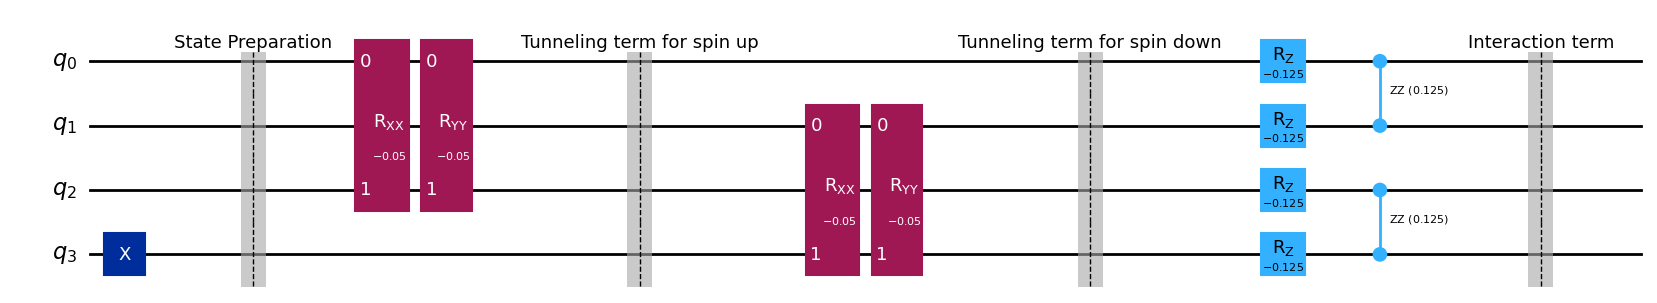

In [124]:
def _trotter_step(qc: QuantumCircuit, J: float, U: float, dt: float) -> None:
    """
    One Trotter step using RXX, RYY, and RZZ gates.

    Args:
        dt: The individual time step size derived from tau / n_trotter.
    """
    # ── Tunneling terms for spin up - XX + YY on q0,q2 ─────────────────────────────
    qc.rxx(-J * dt / 2, 0, 2)
    qc.ryy(-J * dt / 2, 0, 2)
    qc.barrier(label = "Tunneling term for spin up")

    # ── Tunneling terms for spin down - XX + YY on q1,q3 ───────────────────────────
    qc.rxx(-J * dt / 2, 1, 3)
    qc.ryy(-J * dt / 2, 1, 3)
    qc.barrier(label = "Tunneling term for spin down")

    # ── Interaction: site 1 (q0, q1) and site 2 (q2, q3) ────────────────────────
    # Angle u_phase simulates the Coulomb repulsion energy cost
    u_phase = U * dt / 4
    for site_pair in [(0, 1), (2, 3)]:
        i, j = site_pair
        qc.rz(-u_phase, i)
        qc.rz(-u_phase, j)
        qc.rzz(u_phase, i, j)
    qc.barrier(label = "Interaction term")


def make_hubbard_qc(
        J: float = 1.0,
        U: float = 0.0,
        tau: float = 3.1415,
        n_trotter: int = 20,
        init_state: str = "1000"
) -> QuantumCircuit:
    """
    Build a Trotterized Hubbard circuit with constant total time tau.

    Args:
        tau: Constant total evolution time (e.g., pi for Rabi transfer)
        n_trotter: Variable number of steps to adjust Trotter error.
    """
    qc = QuantumCircuit(4)

    # Initialize state (e.g., |1000> for Q3.2 or |1100> for Q3.3)
    for i, bit in enumerate(reversed(init_state)):
        if bit == "1":
            qc.x(i)
    qc.barrier(label = "State Preparation")

    # Proportional time step calculation
    dt = tau / n_trotter

    for _ in range(n_trotter):
        _trotter_step(qc, J=J, U=U, dt=dt)

    return qc

# Q3.1: 1 Trotter step circuit
qc_hub = make_hubbard_qc(J=1.0, U=5.0, tau=0.1, n_trotter=1)
qc_hub.draw('mpl', fold=40)

## Q3.2 — Non-Interacting Dynamics (U=0, J=1)

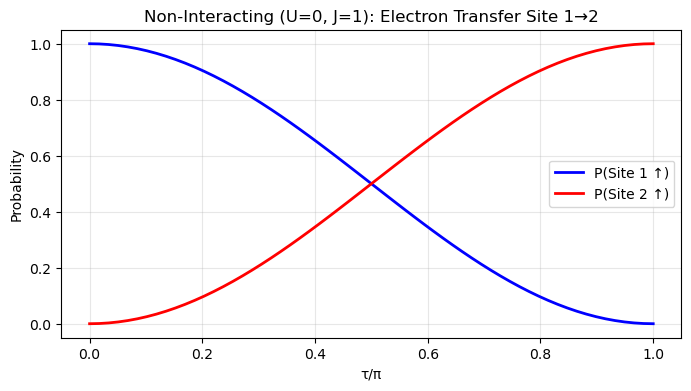

Transfer complete at τ = 3.142


In [136]:
taus = np.linspace(0, np.pi, 60)
p_site1 = [] # To store P(|1000>)
p_site2 = [] # To store P(|0010>)
shots = 1024
simulator = AerSimulator()

# Indices matching Qiskit's little-endian convention
idx_site1 = 8  # Corresponds to |1000> (q3=1, rest 0 --> 0x1000 = 8)
idx_site2 = 2  # Corresponds to |0010> (q1=1, rest 0 --> 0x0010 = 2)

for tau in taus:
    qc = make_hubbard_qc(J=1.0, U=0.0, tau=tau, n_trotter=10, init_state='1000')
    sv = Statevector(qc)
    p_site1.append(abs(sv.data[idx_site1])**2)
    p_site2.append(abs(sv.data[idx_site2])**2)

plt.figure(figsize=(8,4))
plt.plot(taus/np.pi, p_site1, 'b-', lw=2, label='P(Site 1 ↑)')
plt.plot(taus/np.pi, p_site2, 'r-', lw=2, label='P(Site 2 ↑)')
plt.xlabel('τ/π'); plt.ylabel('Probability')
plt.title('Non-Interacting (U=0, J=1): Electron Transfer Site 1→2')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print('Transfer complete at τ =', round(taus[np.argmax(p_site2)],3))

## Q3.3 — Mott Physics (U=10, J=1)

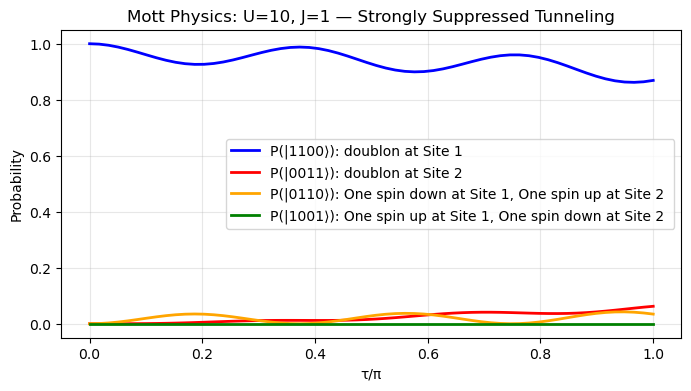

In [137]:
taus = np.linspace(0, np.pi, 60)
p1100, p0011, p0110, p1001 = [], [], [], []
for tau in taus:
    qc = make_hubbard_qc(J=1.0, U=10.0, tau=tau, n_trotter=10, init_state='1100')
    sv = Statevector(qc)
    # |1100⟩: q0=0,q1=0,q2=1,q3=1 → index = 0b1100 = 12
    # |0011⟩: q0=1,q1=1,q2=0,q3=0 → index = 0b0011 = 3
    # |0110⟩: q0=0,q1=1,q2=1,q3=0 → index = 0b0110 = 6
    # |1001⟩: q0=1,q1=0,q2=0,q3=1 → index = 0b0110 = 13
    p1100.append(abs(sv.data[12])**2)
    p0110.append(abs(sv.data[6])**2)
    p0011.append(abs(sv.data[3])**2)
    p1001.append(abs(sv.data[13])**2)

plt.figure(figsize=(8,4))
plt.plot(taus/np.pi, p1100, 'b-', lw=2, label='P(|1100⟩): doublon at Site 1')
plt.plot(taus/np.pi, p0011, 'r-', lw=2, label='P(|0011⟩): doublon at Site 2')
plt.plot(taus/np.pi, p0110, 'orange', lw=2, label='P(|0110⟩): One spin down at Site 1, One spin up at Site 2 ')
plt.plot(taus/np.pi, p1001, 'green', lw=2, label='P(|1001⟩): One spin up at Site 1, One spin down at Site 2 ')
plt.xlabel('τ/π'); plt.ylabel('Probability')
plt.title('Mott Physics: U=10, J=1 — Strongly Suppressed Tunneling')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Discussion: Mott Insulator
- At U=10 >> J=1, the energy cost to create a doublon (two electrons on one site) is U
- Tunneling is suppressed as J²/U (second-order perturbation theory)
- P(|0011⟩) remains near zero throughout — the Mott insulating state
- Compare to U=0 where full transfer occurs at τ=π/2